# Finding Struggling Students
This notebook aims to find a student who attempted most of the 50 problems in the CodeWorkout dataset but achieved very few 100% scores. These students are ideal for mental model analysis because they show more partial progress and errors.

### Candidate Comparison
The table below summarizes the candidates identified for mental model analysis across different performance profiles.

| Role | Student | Avg Score | Problems | Weak Skills | Why Struggling |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Struggling** | 10155 | 0.569 | 46 | 14 | Lots of gaps to find, existing medoid |
| **Average** | 14476 | 0.776 | 50 | 3 | Full 50 problems, good mix of pass/fail |
| **High Performer** | 14475 | 0.981 | 50 | 0 | Almost perfect but not 100%, a few failures to find |

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Allow running from project root
sys.path.append(os.getcwd())
sys.path.append('..') # also try parent if inside experiments/

from utils.dataset import load_joined_datasets, get_best_attempts

In [3]:
# 1. Load data
print("Loading joined datasets...")
full_data = load_joined_datasets(verbose=False)

# 2. Get best attempts (highest score per student-problem pair)
print("Extracting best attempts...")
best_attempts = get_best_attempts(full_data, verbose=False)

print(f"Total best attempts: {len(best_attempts)}")

Loading joined datasets...
Extracting best attempts...
Total best attempts: 15375


In [4]:
# 3. Calculate per-student metrics
student_stats = best_attempts.groupby('SubjectID').agg(
    problems_attempted=('ProblemID', 'count'),
    average_score=('Score', 'mean'),
    perfect_scores=('Score', lambda x: (x == 1.0).sum())
).reset_index()

# 4. Calculate success rate (% of 100% scores)
student_stats['success_rate'] = student_stats['perfect_scores'] / student_stats['problems_attempted']

# 5. Filter for students who attempted almost all 50 problems (e.g., >= 45)
struggling_candidates = student_stats[student_stats['problems_attempted'] >= 45].copy()

# Sort by success rate (ascending) to find those who solve many problems but score poorly
struggling_candidates = struggling_candidates.sort_values('success_rate', ascending=True)

print("Top 10 Stretching/Struggling Candidates (Ordered by lowest success rate):")
display(struggling_candidates.head(10))

Top 10 Stretching/Struggling Candidates (Ordered by lowest success rate):


,SubjectID,problems_attempted,average_score,perfect_scores,success_rate
32,10155,46,0.568885,11,0.239130
125,14189,48,0.662050,18,0.375000
343,14476,50,0.775843,21,0.420000
126,14190,48,0.823288,30,0.625000
251,14367,48,0.834132,30,0.625000
196,14308,50,0.863680,34,0.680000
207,14321,49,0.887912,35,0.714286
203,14316,50,0.888486,38,0.760000
309,14438,50,0.873546,38,0.760000
172,14278,48,0.870971,37,0.770833


Top Candidate: Student 10155.0
Problems Attempted: 46.0
Perfect Scores: 11.0 (23.9%)


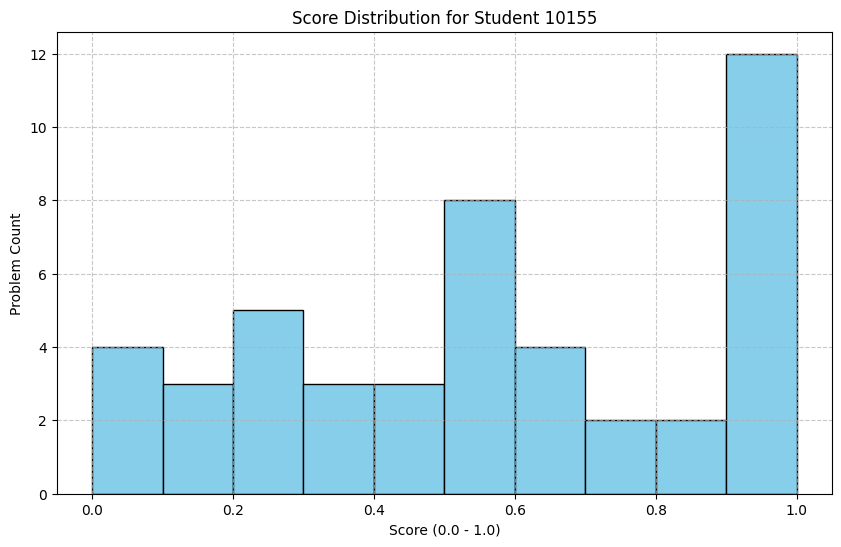

In [6]:
# 6. Choose top student and visualize their performance
top_student = struggling_candidates.iloc[0]
print(f"Top Candidate: Student {top_student['SubjectID']}")
print(f"Problems Attempted: {top_student['problems_attempted']}")
print(f"Perfect Scores: {top_student['perfect_scores']} ({top_student['success_rate']*100:.1f}%)")

# Get this student's scores
student_scores = best_attempts[best_attempts['SubjectID'] == top_student['SubjectID']][['ProblemID', 'Score']]

plt.figure(figsize=(10, 6))
plt.hist(student_scores['Score'], bins=10, color='skyblue', edgecolor='black')
plt.title(f"Score Distribution for Student {int(top_student['SubjectID'])}")
plt.xlabel("Score (0.0 - 1.0)")
plt.ylabel("Problem Count")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

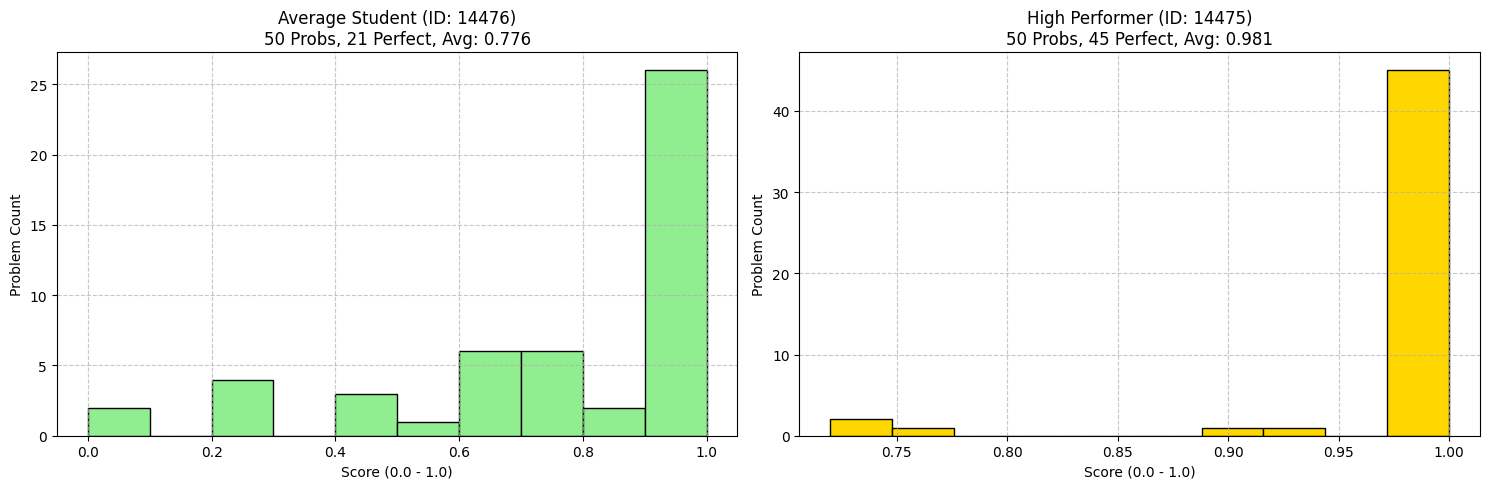

In [7]:
# 7. Visualize score distributions for the other candidates
other_students = [14476, 14475]
student_roles = {14476: "Average Student", 14475: "High Performer"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, sid in enumerate(other_students):
    # Get this student's scores
    student_scores = best_attempts[best_attempts['SubjectID'] == sid][['ProblemID', 'Score']]
    
    # Calculate stats for the title
    problems = len(student_scores)
    perfect = (student_scores['Score'] == 1.0).sum()
    avg = student_scores['Score'].mean()
    
    axes[i].hist(student_scores['Score'], bins=10, color='lightgreen' if sid == 14476 else 'gold', edgecolor='black')
    axes[i].set_title(f"{student_roles[sid]} (ID: {sid})\n{problems} Probs, {perfect} Perfect, Avg: {avg:.3f}")
    axes[i].set_xlabel("Score (0.0 - 1.0)")
    axes[i].set_ylabel("Problem Count")
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [8]:
# 8. Get per-problem scores for all three candidates
candidates = [10155, 14476, 14475]
student_labels = {10155: "Struggling", 14476: "Average", 14475: "High Performer"}

# Filter best attempts for these students
candidate_scores = best_attempts[best_attempts['SubjectID'].isin(candidates)].copy()

# Pivot to see problems as rows and students as columns
pivot_scores = candidate_scores.pivot(index='ProblemID', columns='SubjectID', values='Score')

# Rename columns for clarity using the labels
pivot_scores.columns = [f"{student_labels[sid]} ({int(sid)})" for sid in pivot_scores.columns]

print("Per-Problem Scores for Selected Candidates:")
display(pivot_scores.fillna(0)) # Using fillna(0) to show unattempted as 0 score for comparison

Per-Problem Scores for Selected Candidates:


,Struggling (10155),High Performer (14475),Average (14476)
ProblemID,,,
1,1.000000,1.000000,1.000000
3,0.812500,1.000000,0.750000
5,1.000000,1.000000,0.625000
12,1.000000,1.000000,0.850000
13,1.000000,1.000000,0.826087
17,1.000000,1.000000,1.000000
20,1.000000,1.000000,1.000000
21,1.000000,1.000000,1.000000
22,0.360000,1.000000,1.000000
